# Lecture 2 — Class Exercise
## Bar Charts: World Happiness Report 2023



In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

print("Libraries imported successfully.")

Libraries imported successfully.

In [2]:
# Load the World Happiness Report 2023 dataset
# This path is the Kaggle dataset path used by the original notebook.
DATA_PATH = "/kaggle/input/datasets/ajaypalsinghlo/world-happiness-report-2023/WHR2023.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "WHR2023.csv"
df = pd.read_csv(DATA_PATH)

column_mapping = {
    "Country name": "Country",
    "Ladder score": "Happiness_Score",
    "Logged GDP per capita": "GDP",
    "Social support": "Social_Support",
    "Healthy life expectancy": "Life_Expectancy",
    "Freedom to make life choices": "Freedom",
    "Generosity": "Generosity",
    "Perceptions of corruption": "Corruption"
}
df.rename(columns=column_mapping, inplace=True)

for column in ["Happiness_Score", "GDP", "Social_Support", "Life_Expectancy", "Freedom", "Generosity", "Corruption"]:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

df["Country"] = df["Country"].astype("string").str.strip()
df["Country"] = df["Country"].replace({
    "Türkiye": "Turkey", "Turkiye": "Turkey", "State of Palestine": "Palestinian Territories",
    "Congo (Brazzaville)": "Congo", "Congo (Kinshasa)": "Democratic Republic of the Congo"
})
df = df.dropna(subset=["Country", "Happiness_Score"]).drop_duplicates(subset=["Country"], keep="first").copy()

# Map countries to the same nine regions used for the charts.
region_mapping = {'Austria': 'Western Europe', 'Belgium': 'Western Europe', 'Denmark': 'Western Europe', 'Finland': 'Western Europe', 'France': 'Western Europe', 'Germany': 'Western Europe', 'Iceland': 'Western Europe', 'Ireland': 'Western Europe', 'Luxembourg': 'Western Europe', 'Netherlands': 'Western Europe', 'Norway': 'Western Europe', 'Portugal': 'Western Europe', 'Spain': 'Western Europe', 'Sweden': 'Western Europe', 'Switzerland': 'Western Europe', 'United Kingdom': 'Western Europe', 'Italy': 'Western Europe', 'Greece': 'Western Europe', 'Cyprus': 'Western Europe', 'Malta': 'Western Europe', 'Argentina': 'Latin America', 'Bolivia': 'Latin America', 'Brazil': 'Latin America', 'Chile': 'Latin America', 'Colombia': 'Latin America', 'Costa Rica': 'Latin America', 'Dominican Republic': 'Latin America', 'Ecuador': 'Latin America', 'El Salvador': 'Latin America', 'Guatemala': 'Latin America', 'Honduras': 'Latin America', 'Jamaica': 'Latin America', 'Mexico': 'Latin America', 'Nicaragua': 'Latin America', 'Panama': 'Latin America', 'Paraguay': 'Latin America', 'Peru': 'Latin America', 'Uruguay': 'Latin America', 'Venezuela': 'Latin America', 'China': 'East Asia', 'Japan': 'East Asia', 'Mongolia': 'East Asia', 'South Korea': 'East Asia', 'Taiwan Province of China': 'East Asia', 'Hong Kong S.A.R. of China': 'East Asia', 'Benin': 'Sub-Saharan Africa', 'Botswana': 'Sub-Saharan Africa', 'Burkina Faso': 'Sub-Saharan Africa', 'Burundi': 'Sub-Saharan Africa', 'Cameroon': 'Sub-Saharan Africa', 'Chad': 'Sub-Saharan Africa', 'Comoros': 'Sub-Saharan Africa', 'Congo': 'Sub-Saharan Africa', 'Democratic Republic of the Congo': 'Sub-Saharan Africa', 'Ethiopia': 'Sub-Saharan Africa', 'Gabon': 'Sub-Saharan Africa', 'Gambia': 'Sub-Saharan Africa', 'Ghana': 'Sub-Saharan Africa', 'Guinea': 'Sub-Saharan Africa', 'Ivory Coast': 'Sub-Saharan Africa', 'Kenya': 'Sub-Saharan Africa', 'Lesotho': 'Sub-Saharan Africa', 'Liberia': 'Sub-Saharan Africa', 'Madagascar': 'Sub-Saharan Africa', 'Malawi': 'Sub-Saharan Africa', 'Mali': 'Sub-Saharan Africa', 'Mauritania': 'Sub-Saharan Africa', 'Mauritius': 'Sub-Saharan Africa', 'Mozambique': 'Sub-Saharan Africa', 'Namibia': 'Sub-Saharan Africa', 'Niger': 'Sub-Saharan Africa', 'Nigeria': 'Sub-Saharan Africa', 'Senegal': 'Sub-Saharan Africa', 'Sierra Leone': 'Sub-Saharan Africa', 'South Africa': 'Sub-Saharan Africa', 'Tanzania': 'Sub-Saharan Africa', 'Togo': 'Sub-Saharan Africa', 'Uganda': 'Sub-Saharan Africa', 'Zambia': 'Sub-Saharan Africa', 'Zimbabwe': 'Sub-Saharan Africa', 'Afghanistan': 'South Asia', 'Bangladesh': 'South Asia', 'India': 'South Asia', 'Nepal': 'South Asia', 'Pakistan': 'South Asia', 'Sri Lanka': 'South Asia', 'Cambodia': 'Southeast Asia', 'Indonesia': 'Southeast Asia', 'Laos': 'Southeast Asia', 'Malaysia': 'Southeast Asia', 'Myanmar': 'Southeast Asia', 'Philippines': 'Southeast Asia', 'Singapore': 'Southeast Asia', 'Thailand': 'Southeast Asia', 'Vietnam': 'Southeast Asia', 'Albania': 'Central and Eastern Europe', 'Armenia': 'Central and Eastern Europe', 'Azerbaijan': 'Central and Eastern Europe', 'Belarus': 'Central and Eastern Europe', 'Bosnia and Herzegovina': 'Central and Eastern Europe', 'Bulgaria': 'Central and Eastern Europe', 'Croatia': 'Central and Eastern Europe', 'Czechia': 'Central and Eastern Europe', 'Estonia': 'Central and Eastern Europe', 'Georgia': 'Central and Eastern Europe', 'Hungary': 'Central and Eastern Europe', 'Kazakhstan': 'Central and Eastern Europe', 'Kosovo': 'Central and Eastern Europe', 'Kyrgyzstan': 'Central and Eastern Europe', 'Latvia': 'Central and Eastern Europe', 'Lithuania': 'Central and Eastern Europe', 'Moldova': 'Central and Eastern Europe', 'Montenegro': 'Central and Eastern Europe', 'North Macedonia': 'Central and Eastern Europe', 'Poland': 'Central and Eastern Europe', 'Romania': 'Central and Eastern Europe', 'Russia': 'Central and Eastern Europe', 'Serbia': 'Central and Eastern Europe', 'Slovakia': 'Central and Eastern Europe', 'Slovenia': 'Central and Eastern Europe', 'Tajikistan': 'Central and Eastern Europe', 'Ukraine': 'Central and Eastern Europe', 'Uzbekistan': 'Central and Eastern Europe', 'Algeria': 'Middle East and North Africa', 'Bahrain': 'Middle East and North Africa', 'Egypt': 'Middle East and North Africa', 'Iran': 'Middle East and North Africa', 'Iraq': 'Middle East and North Africa', 'Israel': 'Middle East and North Africa', 'Jordan': 'Middle East and North Africa', 'Kuwait': 'Middle East and North Africa', 'Lebanon': 'Middle East and North Africa', 'Libya': 'Middle East and North Africa', 'Morocco': 'Middle East and North Africa', 'Oman': 'Middle East and North Africa', 'Palestinian Territories': 'Middle East and North Africa', 'Qatar': 'Middle East and North Africa', 'Saudi Arabia': 'Middle East and North Africa', 'Syria': 'Middle East and North Africa', 'Tunisia': 'Middle East and North Africa', 'Turkey': 'Middle East and North Africa', 'United Arab Emirates': 'Middle East and North Africa', 'Yemen': 'Middle East and North Africa', 'Australia': 'North America and ANZ', 'Canada': 'North America and ANZ', 'New Zealand': 'North America and ANZ', 'United States': 'North America and ANZ'}
df["Region"] = df["Country"].map(region_mapping)
unmapped_countries = sorted(df.loc[df["Region"].isna(), "Country"].unique())
if unmapped_countries:
    raise ValueError(f"Countries without a region mapping: {unmapped_countries}")

print("Dataset loaded successfully!")
print("Final dataset shape:", df.shape)
print("Number of countries:", df["Country"].nunique())
print("Number of regions:", df["Region"].nunique())
print("\nCountries per region:")
print(df["Region"].value_counts())
print("\nGlobal average happiness score:", round(df["Happiness_Score"].mean(), 2))
display(df.head())

Dataset loaded successfully!
Final dataset shape: (137, 20)
Number of countries: 137
Number of regions: 9

Countries per region:
Region
Sub-Saharan Africa              33
Central and Eastern Europe      26
Western Europe                  20
Latin America                   19
Middle East and North Africa    14
Southeast Asia                   9
East Asia                        6
South Asia                       6
North America and ANZ            4

Global average happiness score: 5.54

,Country,Happiness_Score,Standard error of ladder score,upperwhisker,lowerwhisker,GDP,Social_Support,Life_Expectancy,Freedom,Generosity,Corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual,Region
0,Finland,7.804,0.036,7.875,7.733,10.792,0.969,71.150,0.961,-0.019,0.182,1.778,1.888,1.585,0.535,0.772,0.126,0.535,2.363,Western Europe
1,Denmark,7.586,0.041,7.667,7.506,10.962,0.954,71.250,0.934,0.134,0.196,1.778,1.949,1.548,0.537,0.734,0.208,0.525,2.084,Western Europe
2,Iceland,7.530,0.049,7.625,7.434,10.896,0.983,72.050,0.936,0.211,0.668,1.778,1.926,1.620,0.559,0.738,0.250,0.187,2.250,Western Europe
3,Israel,7.473,0.032,7.535,7.411,10.639,0.943,72.697,0.809,-0.023,0.708,1.778,1.833,1.521,0.577,0.569,0.124,0.158,2.691,Middle East and North Africa
4,Netherlands,7.403,0.029,7.460,7.346,10.942,0.930,71.550,0.887,0.213,0.379,1.778,1.942,1.488,0.545,0.672,0.251,0.394,2.110,Western Europe


## Task 1 — Regional comparison

The bars use a zero baseline and are sorted so the highest-scoring region appears at the top. The leading region is highlighted.

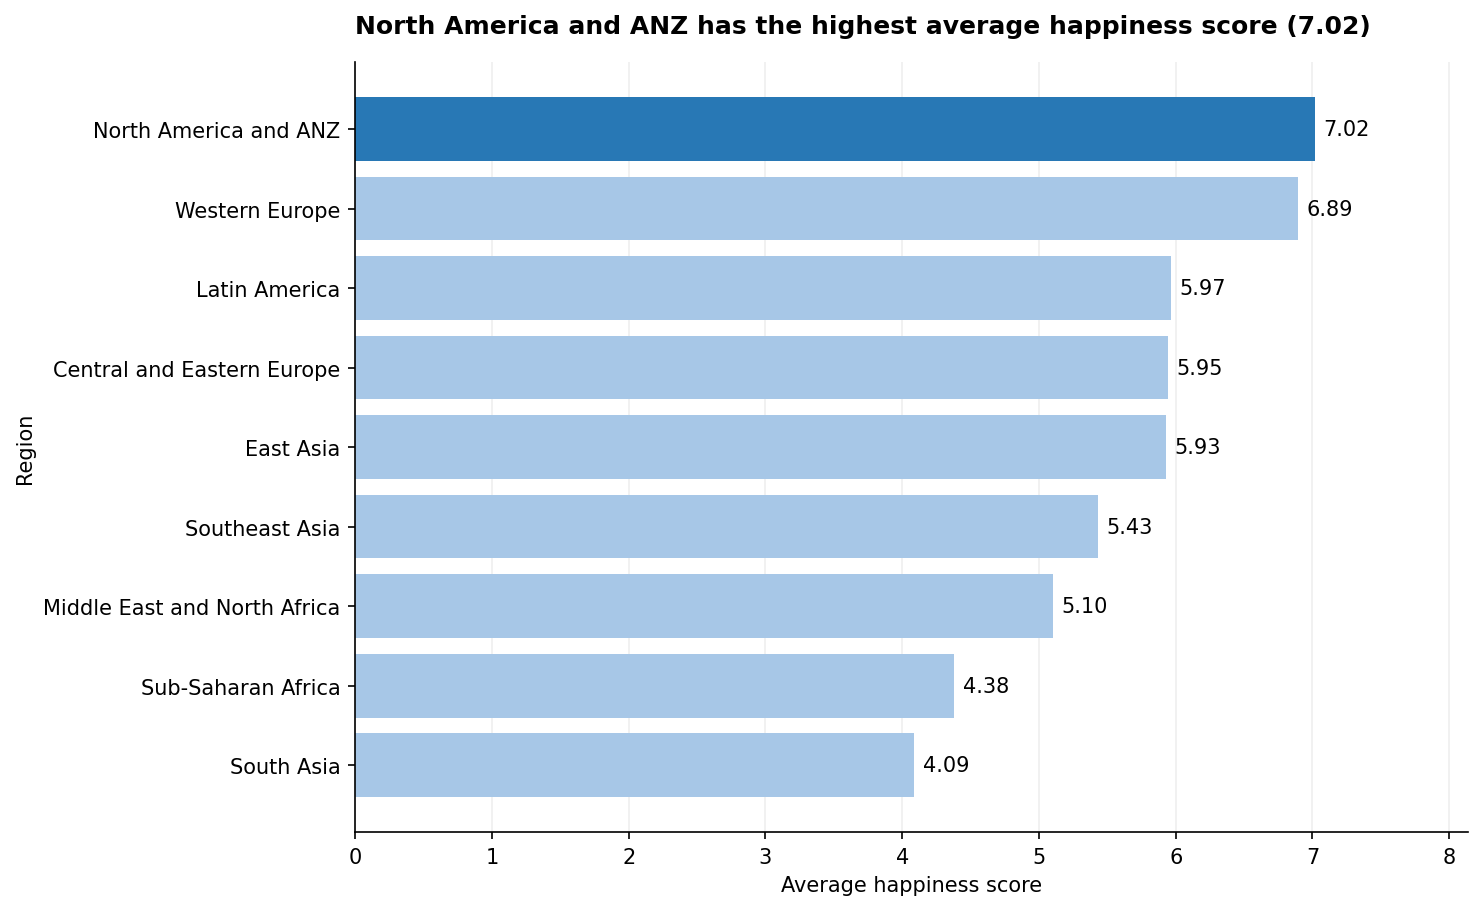

Highest-scoring region: North America and ANZ (7.02)

Regional average happiness scores:

Region,Happiness_Score
North America and ANZ,7.02
Western Europe,6.89
Latin America,5.97
Central and Eastern Europe,5.95
East Asia,5.93
Southeast Asia,5.43
Middle East and North Africa,5.10
Sub-Saharan Africa,4.38
South Asia,4.09


In [3]:
# Task 1: Average happiness score by region
regional_happiness = (
    df.groupby("Region", as_index=False)["Happiness_Score"]
    .mean()
    .sort_values("Happiness_Score", ascending=True)
)
top_region = regional_happiness.loc[regional_happiness["Happiness_Score"].idxmax(), "Region"]
top_score = regional_happiness["Happiness_Score"].max()

fig, ax = plt.subplots(figsize=(10, 6.2))
colors = ["#2878B5" if region == top_region else "#A7C7E7" for region in regional_happiness["Region"]]
bars = ax.barh(regional_happiness["Region"], regional_happiness["Happiness_Score"], color=colors)
ax.bar_label(bars, fmt="%.2f", padding=4)
ax.set_xlim(0, regional_happiness["Happiness_Score"].max() * 1.16)
ax.set_xlabel("Average happiness score")
ax.set_ylabel("Region")
ax.set_title(f"{top_region} has the highest average happiness score ({top_score:.2f})", loc="left", fontweight="bold", pad=14)
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()
print("Regional average happiness scores:")
display(regional_happiness.sort_values("Happiness_Score", ascending=False).round(2))

## Task 2 — Top 8 versus bottom 8 countries

Blue represents the top eight and orange the bottom eight. The dashed line marks the actual global average calculated from the dataset.

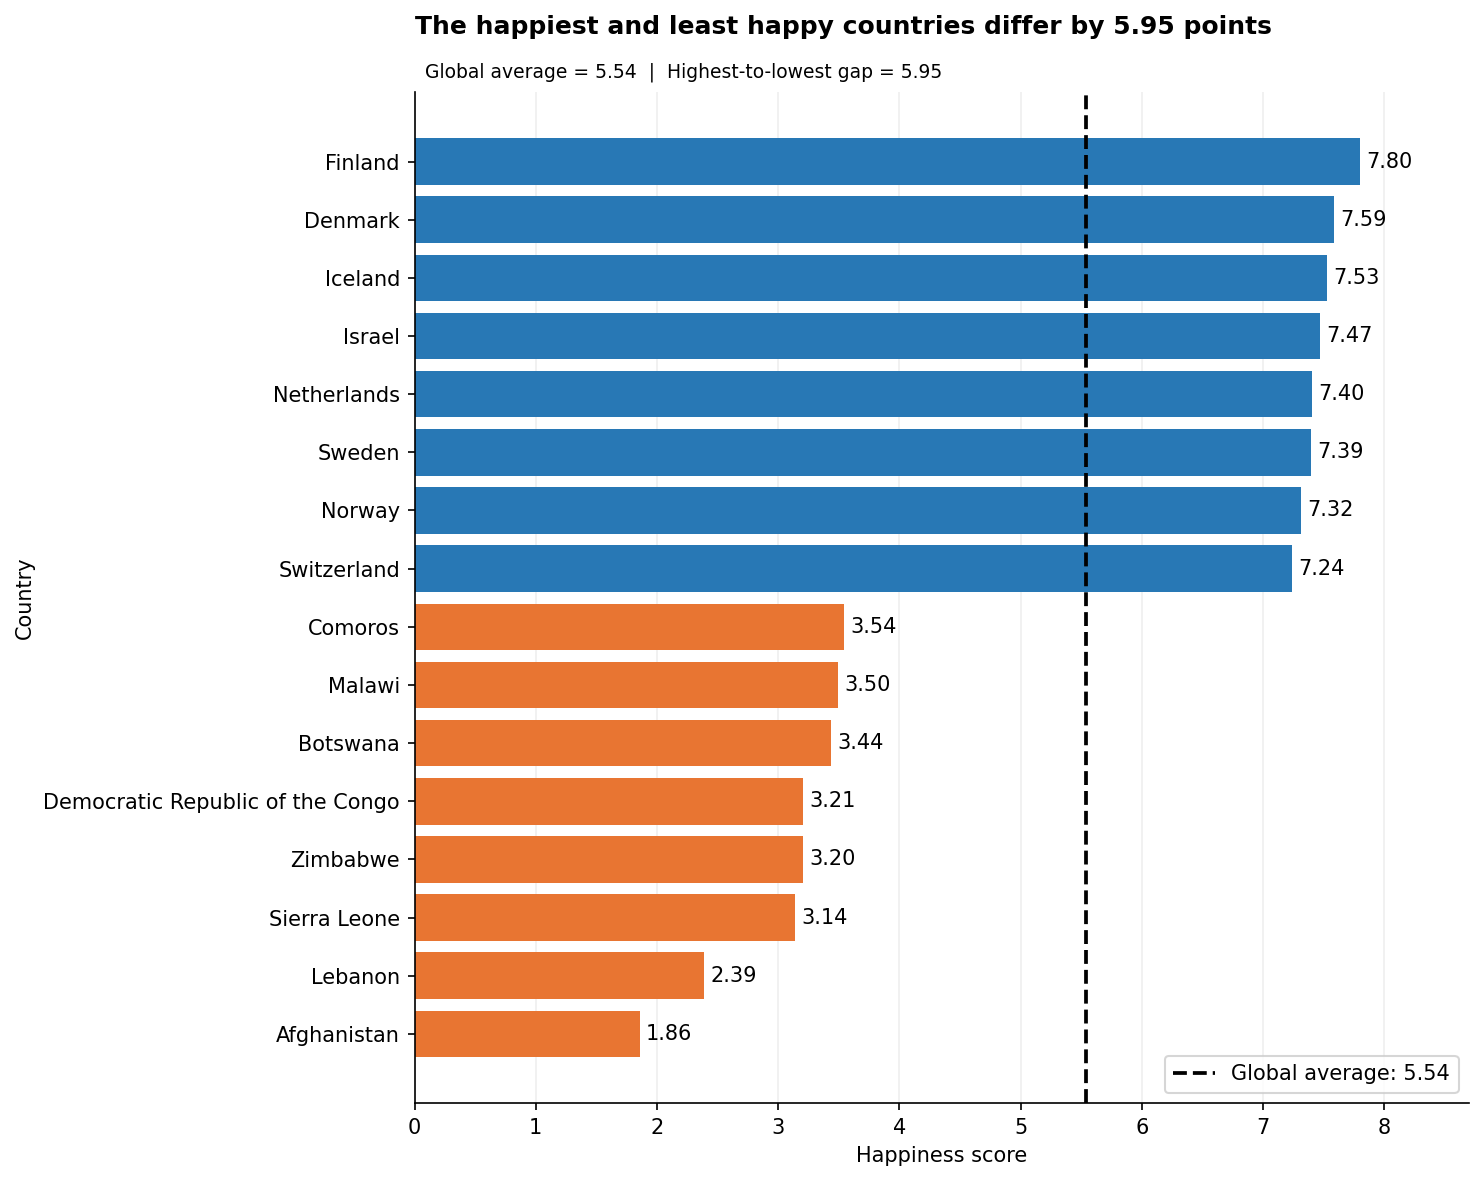

Global average happiness score: 5.54
Highest score: 7.80
Lowest score: 1.86
Happiness gap: 5.95

In [4]:
# Task 2: Top 8 vs bottom 8 happiest countries
global_average = df["Happiness_Score"].mean()
top_8 = df.nlargest(8, "Happiness_Score")[["Country", "Happiness_Score"]].copy()
bottom_8 = df.nsmallest(8, "Happiness_Score")[["Country", "Happiness_Score"]].copy()
top_8["Group"] = "Top 8 Happiest"
bottom_8["Group"] = "Bottom 8 Happiest"
comparison = pd.concat([top_8, bottom_8], ignore_index=True).sort_values("Happiness_Score", ascending=True)
highest_score = df["Happiness_Score"].max()
lowest_score = df["Happiness_Score"].min()
happiness_gap = highest_score - lowest_score

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#2878B5" if group == "Top 8 Happiest" else "#E87532" for group in comparison["Group"]]
bars = ax.barh(comparison["Country"], comparison["Happiness_Score"], color=colors)
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.axvline(global_average, color="black", linestyle="--", linewidth=1.8, label=f"Global average: {global_average:.2f}")
ax.set_xlim(0, 8.7)
ax.set_xlabel("Happiness score")
ax.set_ylabel("Country")
ax.set_title(f"The happiest and least happy countries differ by {happiness_gap:.2f} points", loc="left", fontweight="bold", pad=28)
ax.text(0.01, 1.015, f"Global average = {global_average:.2f}  |  Highest-to-lowest gap = {happiness_gap:.2f}", transform=ax.transAxes, fontsize=9)
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()
print(f"Global average happiness score: {global_average:.2f}")
print(f"Highest score: {highest_score:.2f}")
print(f"Lowest score: {lowest_score:.2f}")
print(f"Happiness gap: {happiness_gap:.2f}")

## Task 3 — Optional stretch goal

This grouped chart compares logged GDP per capita and freedom scores across the five specified regions. Note that GDP and freedom are different scales, so interpret their magnitudes separately.

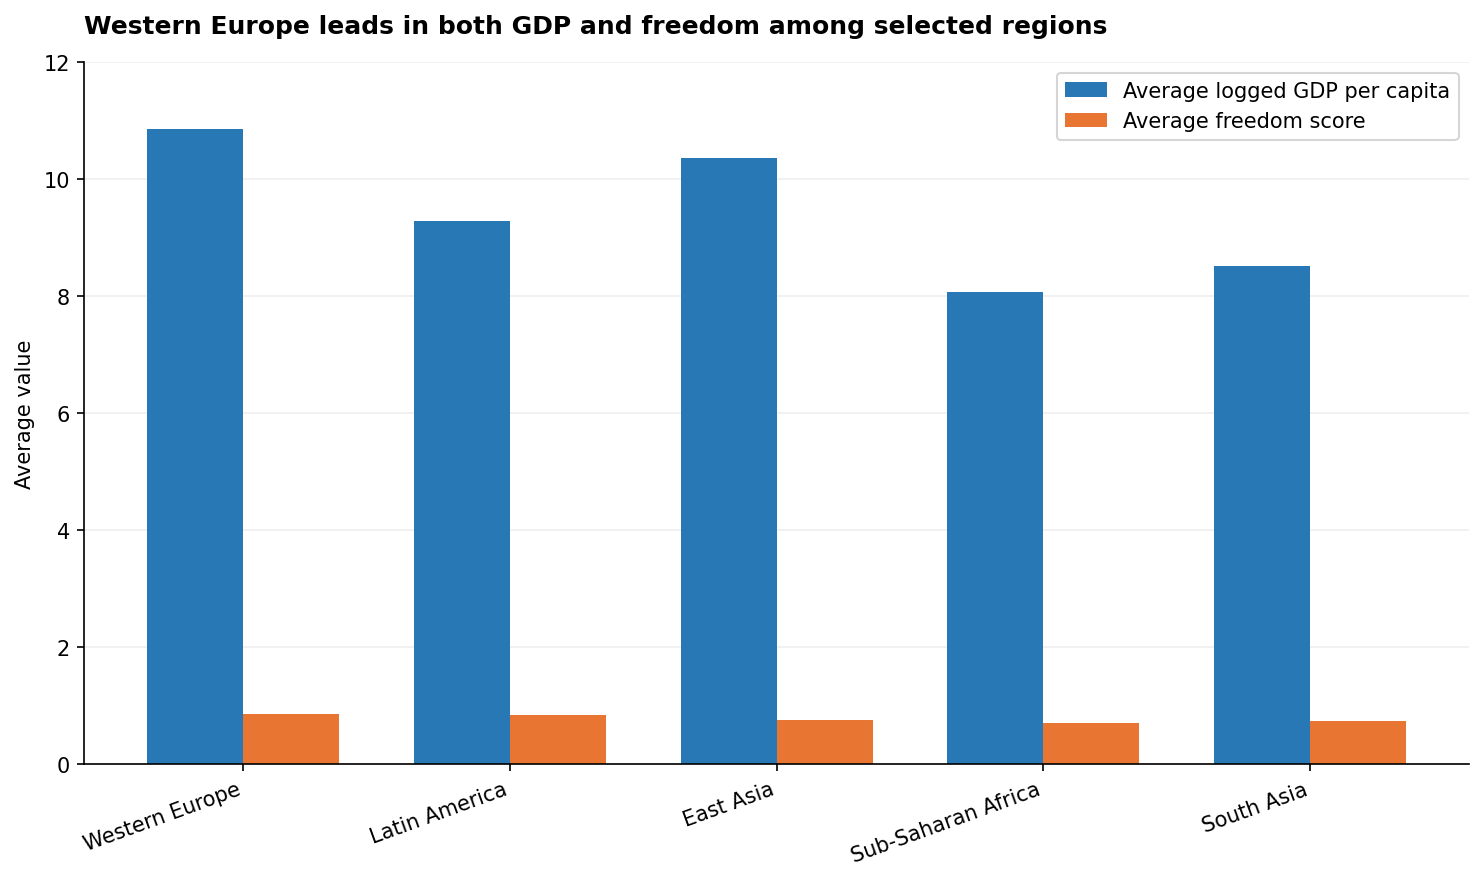

Region,Average_GDP,Average_Freedom
Western Europe,10.855200,0.853150
Latin America,9.290053,0.836895
East Asia,10.363667,0.765000
Sub-Saharan Africa,8.071879,0.703485
South Asia,8.509167,0.747500


In [5]:
# Task 3 (optional stretch): GDP vs freedom across selected regions
selected_regions = ["Western Europe", "Latin America", "East Asia", "Sub-Saharan Africa", "South Asia"]
selected_df = df[df["Region"].isin(selected_regions)].copy()
regional_comparison = selected_df.groupby("Region", as_index=False).agg(
    Average_GDP=("GDP", "mean"), Average_Freedom=("Freedom", "mean")
)
regional_comparison["Region"] = pd.Categorical(regional_comparison["Region"], categories=selected_regions, ordered=True)
regional_comparison = regional_comparison.sort_values("Region")

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(regional_comparison))
width = 0.36
ax.bar(x - width / 2, regional_comparison["Average_GDP"], width, label="Average logged GDP per capita", color="#2878B5")
ax.bar(x + width / 2, regional_comparison["Average_Freedom"], width, label="Average freedom score", color="#E87532")
ax.set_xticks(x, regional_comparison["Region"], rotation=20, ha="right")
ax.set_ylabel("Average value")
ax.set_ylim(0, 12)
ax.set_title("Western Europe leads in both GDP and freedom among selected regions", loc="left", fontweight="bold", pad=14)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend()
fig.tight_layout()
plt.show()
display(regional_comparison)